In [1]:
import numpy as np
from matplotlib import pyplot as plt
import torch

In [2]:
# Data load
data=np.load("/home/kjaworski/Pulpit/Thermal_diffusivity_est/Diffusivity_estimation_simple/data/2026_03_18_CFRP_FBH_3s_30s_top_symetrical.npz",allow_pickle=True)

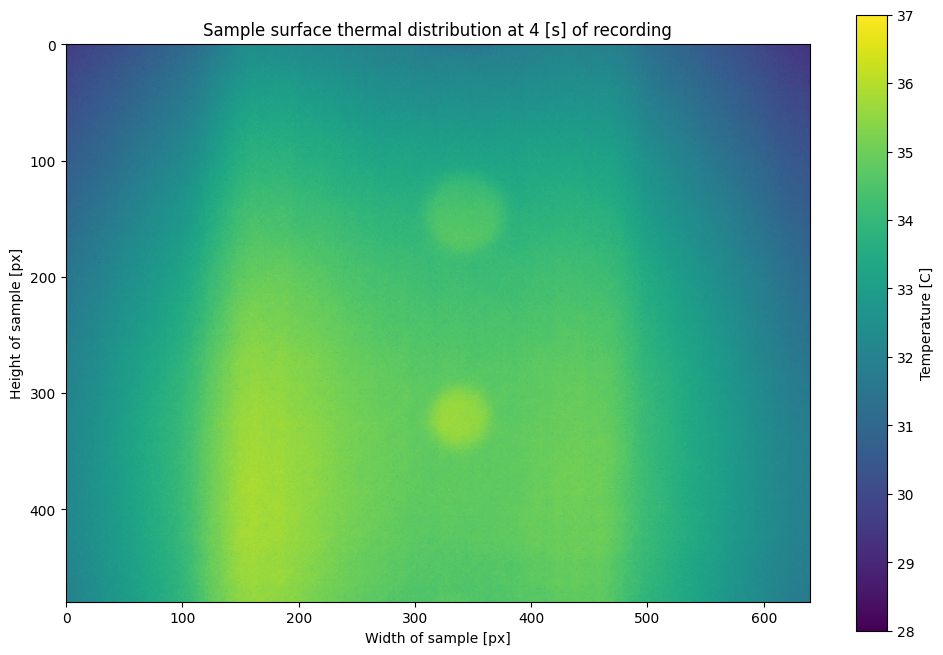

In [3]:
# Plotting the camera recording at given frame
plt.figure(figsize=(12,8))
plt.imshow(data['data'][200,:,:]/100-273.5,vmin=28,vmax=37)
plt.xlabel('Width of sample [px]')
plt.ylabel('Height of sample [px]')
plt.title('Sample surface thermal distribution at 4 [s] of recording')
plt.colorbar(label='Temperature [C]')

In [4]:
from scipy.signal import savgol_filter

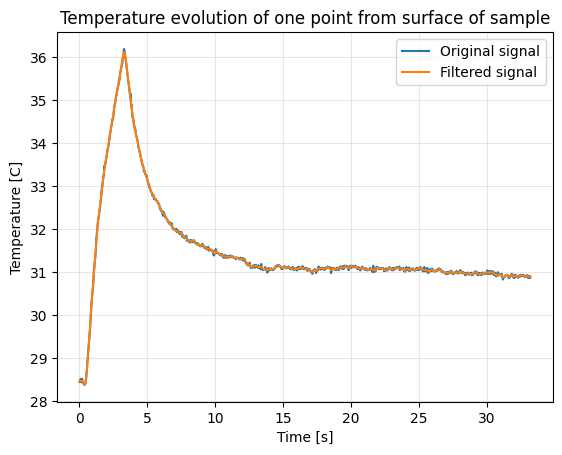

In [5]:
T,H,W=data['data'].shape
H_center=H//2
W_center=W//2

x_t=data['data'][:,H_center,W_center]/100-273.5 # Conversion to the [C]
t=np.linspace(0,T/50,T)

x_t_sav = savgol_filter(x_t, window_length=19, polyorder=3, axis=0)

plt.plot(t,x_t,label='Original signal')
plt.plot(t,x_t_sav,label='Filtered signal')

plt.grid(alpha=0.3)
plt.xlabel('Time [s]')
plt.ylabel('Temperature [C]')
plt.title('Temperature evolution of one point from surface of sample')
plt.legend()